# Matplotlib Question on Datasets

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/anilr/Downloads/matplotlib_sales_clean_1000 - matplotlib_sales_clean_1000.csv")
df.head(10
    
)


,Order_ID,Order_Date,City,Product_Category,Customer_Segment,Customer_Age,Units_Sold,Unit_Price,Discount_Pct,Customer_Rating,Gross_Sales,Discount_Amount,Revenue,Cost,Profit
0,ORD00849,2025-01-01,Pune,Home & Kitchen,Budget,36,5,13359.07,2.33,3.4,66795.35,1556.33,65239.02,45347.81,19891.21
1,ORD00678,2025-01-01,Hyderabad,Home & Kitchen,Premium,42,2,13594.04,19.92,3.9,27188.08,5415.87,21772.21,15198.49,6573.72
2,ORD00649,2025-01-01,Delhi,Home & Kitchen,Budget,25,5,1657.67,2.85,2.7,8288.35,236.22,8052.13,4569.99,3482.14
3,ORD00756,2025-01-01,Bengaluru,Home & Kitchen,Premium,31,3,2487.88,32.94,3.7,7463.64,2458.52,5005.12,3547.03,1458.09
4,ORD00992,2025-01-01,Delhi,Beauty,Regular,43,4,20911.12,26.06,4.2,83644.48,21797.75,61846.73,36979.40,24867.33
5,ORD00447,2025-01-01,Delhi,Beauty,Premium,18,10,1688.74,0.14,3.8,16887.40,23.64,16863.76,9812.07,7051.69
6,ORD00207,2025-01-02,Mumbai,Beauty,Budget,57,4,20083.19,12.56,3.3,80332.76,10089.79,70242.97,49057.55,21185.42
7,ORD00264,2025-01-02,Mumbai,Beauty,Regular,40,2,20351.63,9.84,3.3,40703.26,4005.20,36698.06,24894.02,11804.04
8,ORD00064,2025-01-02,Chennai,Beauty,Regular,33,10,15646.87,15.94,4.8,156468.70,24941.11,131527.59,75134.95,56392.64
9,ORD00896,2025-01-03,Pune,Beauty,Premium,61,10,1912.34,0.21,3.9,19123.40,40.16,19083.24,12493.73,6589.51


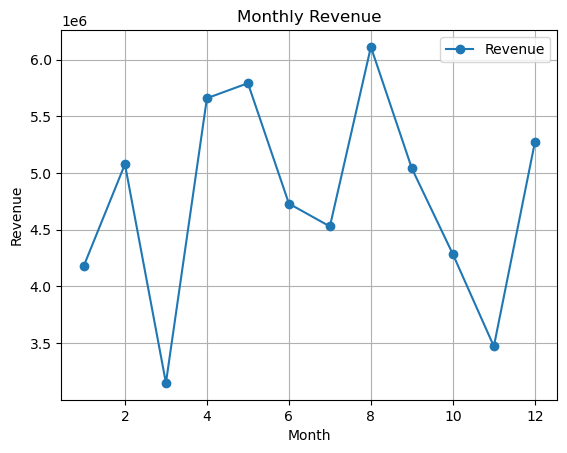

In [34]:
# 1. Plot monthly Revenue as a line chart. Add title, axis labels, markers, grid, and legend.
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly = df.groupby(df["Order_Date"].dt.month)["Revenue"].sum()

plt.plot(monthly.index, monthly.values, marker='o', label='Revenue')

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.legend()

plt.show()

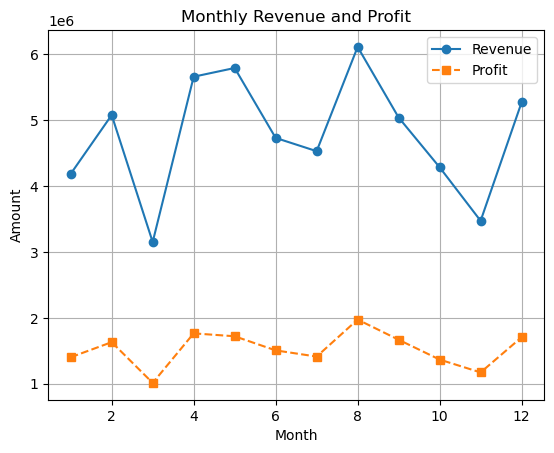

In [35]:
# 2. Plot monthly Revenue and Profit on the same chart using different line styles.
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly = df.groupby(df["Order_Date"].dt.month)[["Revenue", "Profit"]].sum()

plt.plot(monthly.index, monthly["Revenue"], linestyle='-', marker='o', label='Revenue')
plt.plot(monthly.index, monthly["Profit"], linestyle='--', marker='s', label='Profit')

plt.title("Monthly Revenue and Profit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)

plt.show()

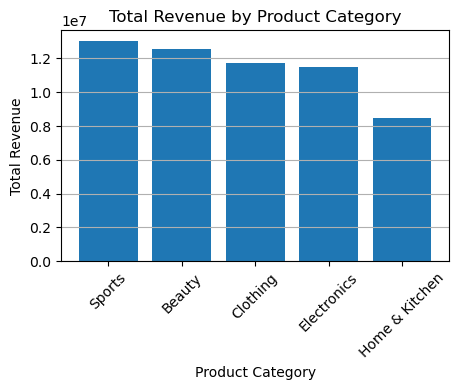

In [36]:
# 3. Create a bar chart of total Revenue by Product_Category and sort the categories from highest to lowest revenue.

category_revenue = (df.groupby("Product_Category")["Revenue"].sum().sort_values(ascending=False))

plt.figure(figsize=(5, 3))

plt.bar(category_revenue.index,category_revenue.values)

plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

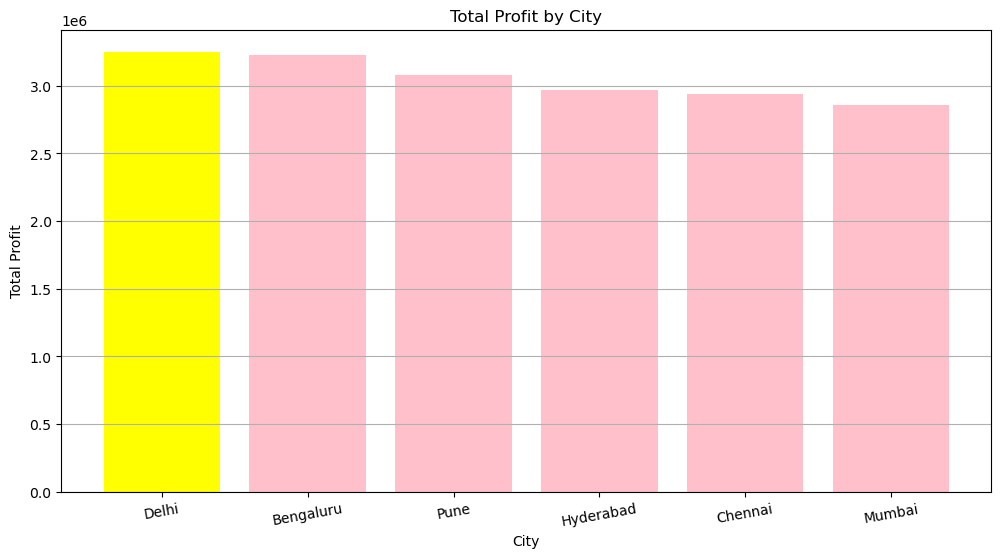

In [37]:
# 4. Create a bar chart of total Profit by City and highlight the city with the highest profit.


# Total Profit by City
city_profit = (df.groupby("City")["Profit"].sum().sort_values(ascending=False))

# City with highest profit
max_city = city_profit.idxmax()
max_profit = city_profit.max()

# Colors
colors = ['pink'] * len(city_profit)
colors[list(city_profit.index).index(max_city)] = 'yellow'

# Bar Chart
plt.figure(figsize=(12, 6))
plt.bar(city_profit.index, city_profit.values, color=colors)


plt.title("Total Profit by City")
plt.xlabel("City")
plt.ylabel("Total Profit")
plt.xticks(rotation=10)
plt.grid(axis='y')



plt.show()

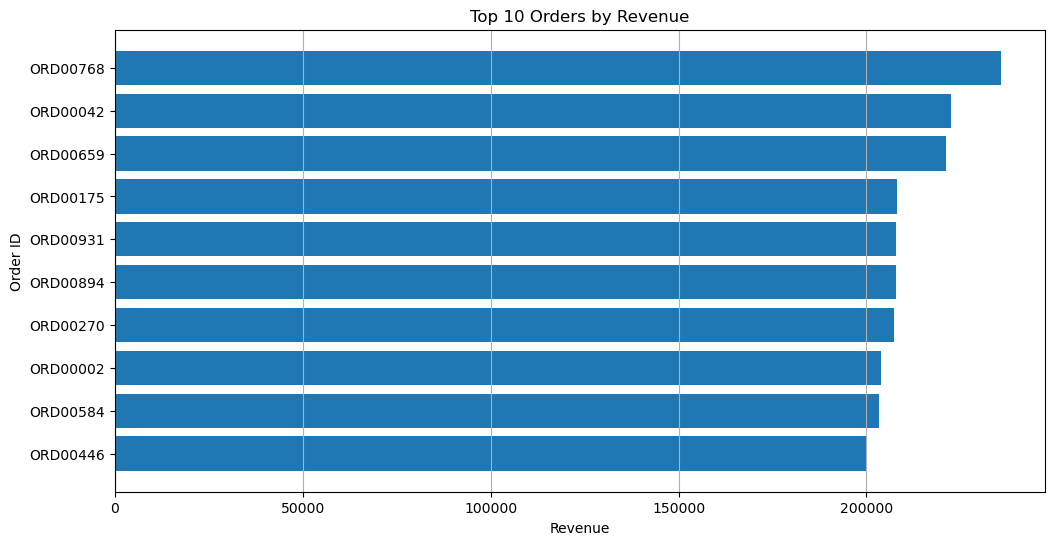

In [38]:
# 5. Create a horizontal bar chart showing the top 10 orders based on Revenue.

top10_orders = df.nlargest(10, "Revenue")

plt.figure(figsize=(12, 6))

plt.barh(
    top10_orders["Order_ID"],
    top10_orders["Revenue"]
)

plt.title("Top 10 Orders by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Order ID")

plt.grid(axis='x')

# Highest revenue at top
plt.gca().invert_yaxis()

plt.show()

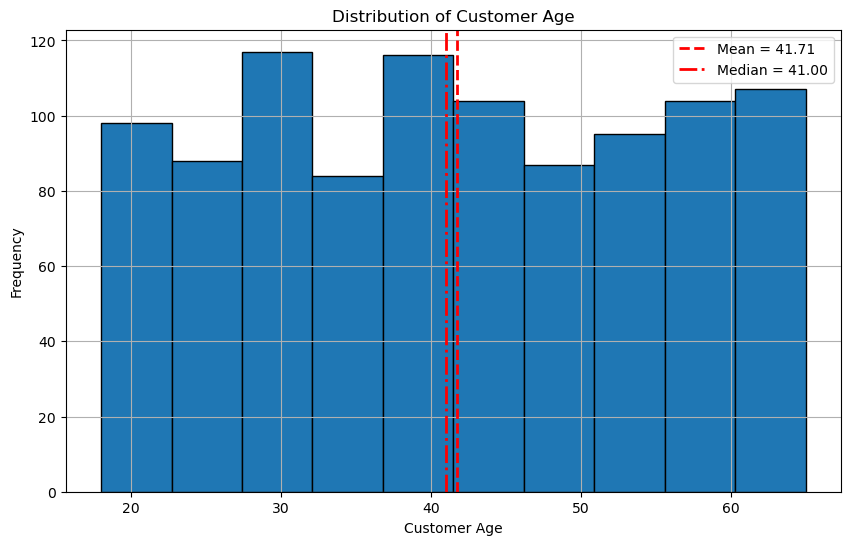

In [39]:
# 6. Create a histogram of Customer_Age using 10 appropriate bins. Add mean and median lines.

mean_age = df["Customer_Age"].mean()
median_age = df["Customer_Age"].median()

plt.figure(figsize=(10, 6))

# Histogram
plt.hist(df["Customer_Age"], bins=10, edgecolor="black")

# Mean Line
plt.axvline(
    mean_age,
    linestyle="--",
    color = "Red",
    linewidth=2,
    label=f"Mean = {mean_age:.2f}"
)

# Median Line
plt.axvline(
    median_age,
    linestyle="-.",
    color = "Red",
    linewidth=2,
    label=f"Median = {median_age:.2f}"
)

plt.title("Distribution of Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Frequency")
plt.grid(True)
plt.legend()

plt.show()

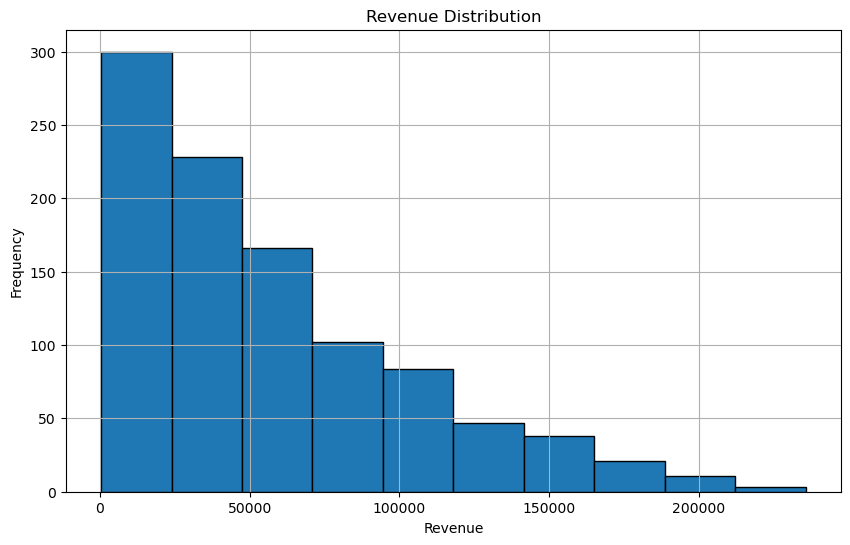

In [40]:
# 7. Create a histogram of Revenue and explain visually whether the distribution appears symmetric or skewed.
plt.figure(figsize=(10, 6))

plt.hist(df["Revenue"], bins=10, edgecolor="black")

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

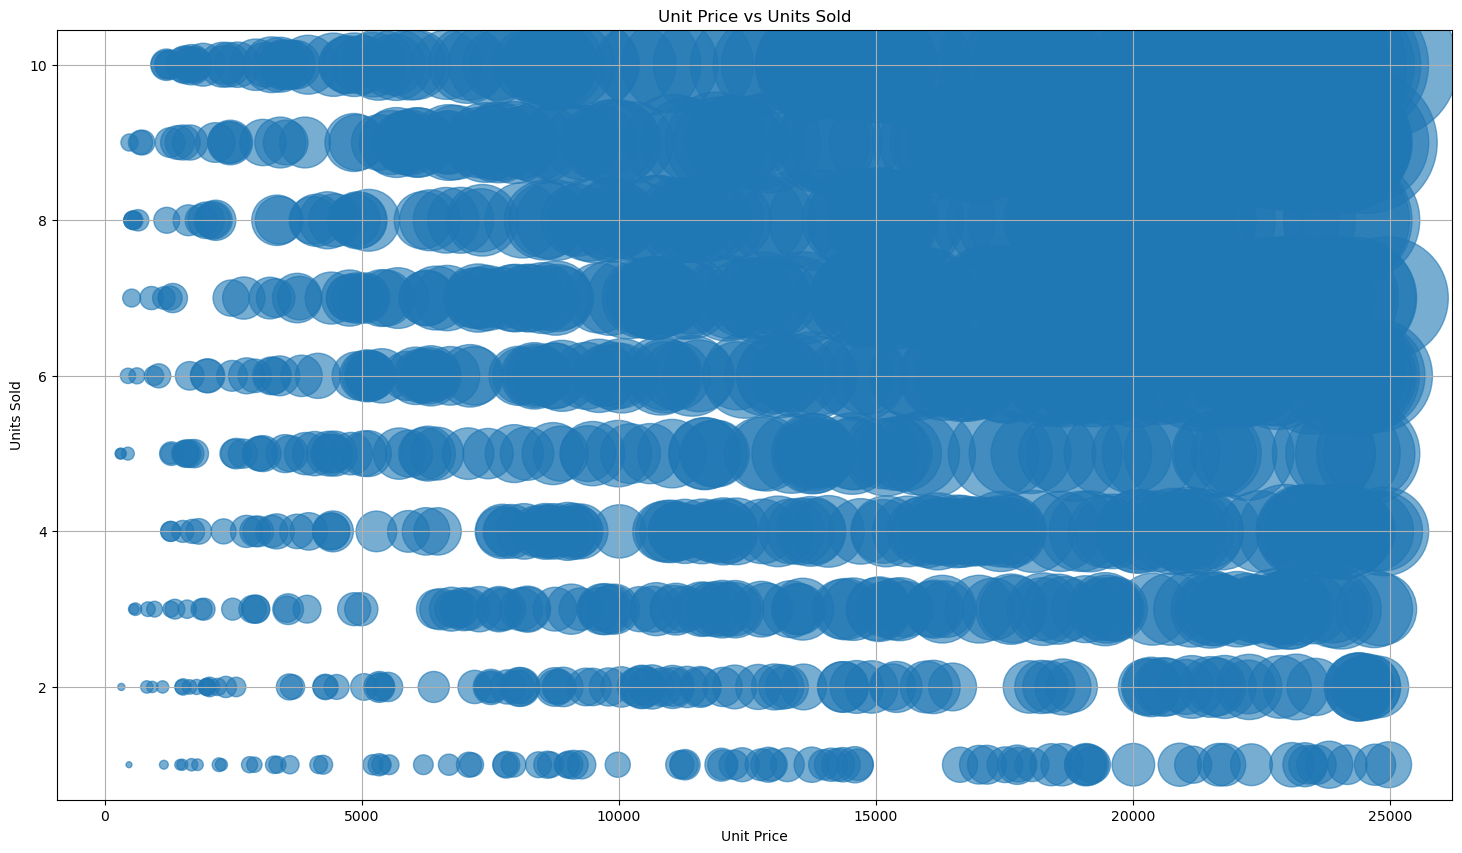

In [41]:
# 8. Create a scatter plot of Unit_Price vs Units_Sold. Use different marker sizes based on Revenue.
plt.figure(figsize=(18, 10))

plt.scatter(df["Unit_Price"], df["Units_Sold"],s=df["Revenue"] / 20,alpha=0.6)

plt.title("Unit Price vs Units Sold")
plt.xlabel("Unit Price")
plt.ylabel("Units Sold")
plt.grid(True)

plt.show()

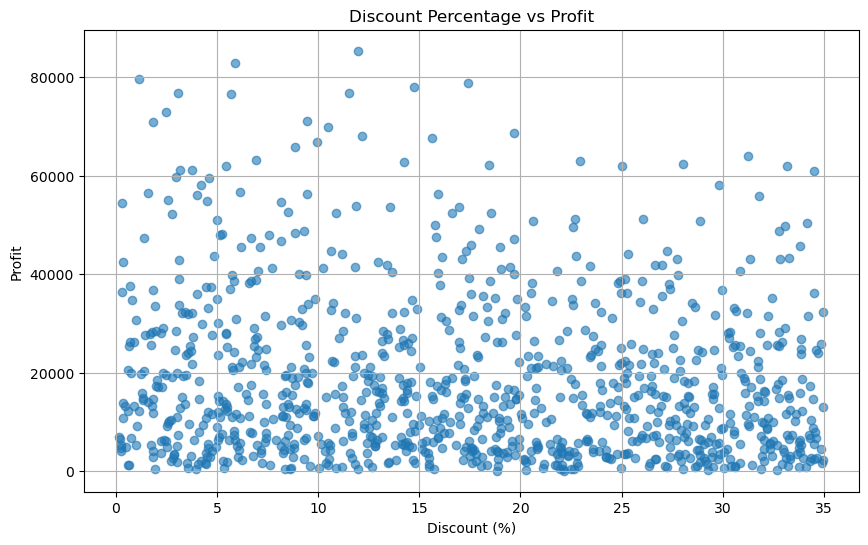

In [42]:
# 9. Create a scatter plot of Discount_Pct vs Profit and determine visually whether higher discounts are associated with lower profit.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount_Pct"],
    df["Profit"],
    alpha=0.6
)

plt.title("Discount Percentage vs Profit")
plt.xlabel("Discount (%)")
plt.ylabel("Profit")
plt.grid(True)

plt.show()

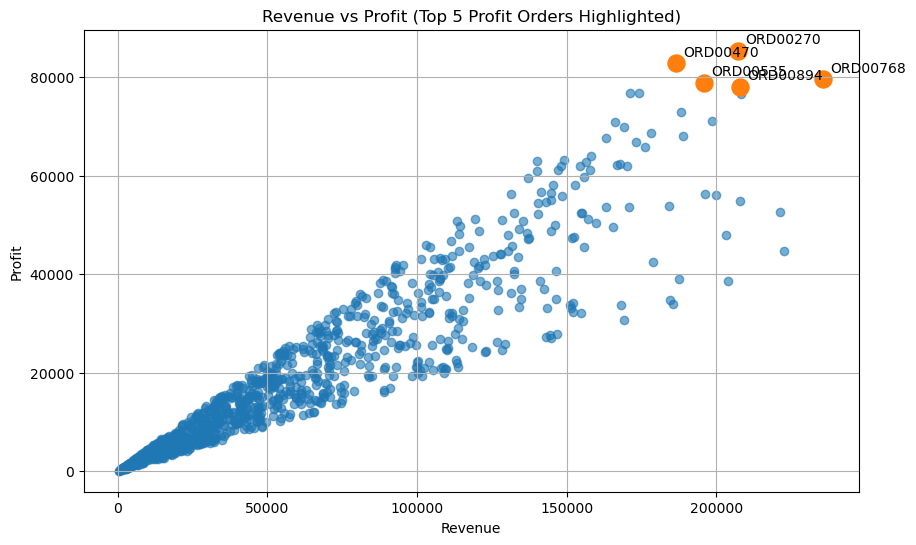

In [43]:
# 10. Create a scatter plot of Revenue vs Profit and highlight the five orders having the highest profit.Create a scatter plot of Revenue vs Profit and highlight the five orders having the highest profit.
import pandas as pd
import matplotlib.pyplot as plt

# Top 5 highest profit orders
top5 = df.nlargest(5, 'Profit')

plt.figure(figsize=(10,6))

# All orders
plt.scatter(df['Revenue'], df['Profit'], alpha=0.6)

# Highlight top 5 profit orders
plt.scatter(top5['Revenue'], top5['Profit'], s=150)

# Add labels for top 5 orders
for _, row in top5.iterrows():
    plt.annotate(
        row['Order_ID'],
        (row['Revenue'], row['Profit']),
        xytext=(5,5),
        textcoords='offset points'
    )

plt.xlabel("Revenue")
plt.ylabel("Profit")
plt.title("Revenue vs Profit (Top 5 Profit Orders Highlighted)")
plt.grid(True)
plt.show()

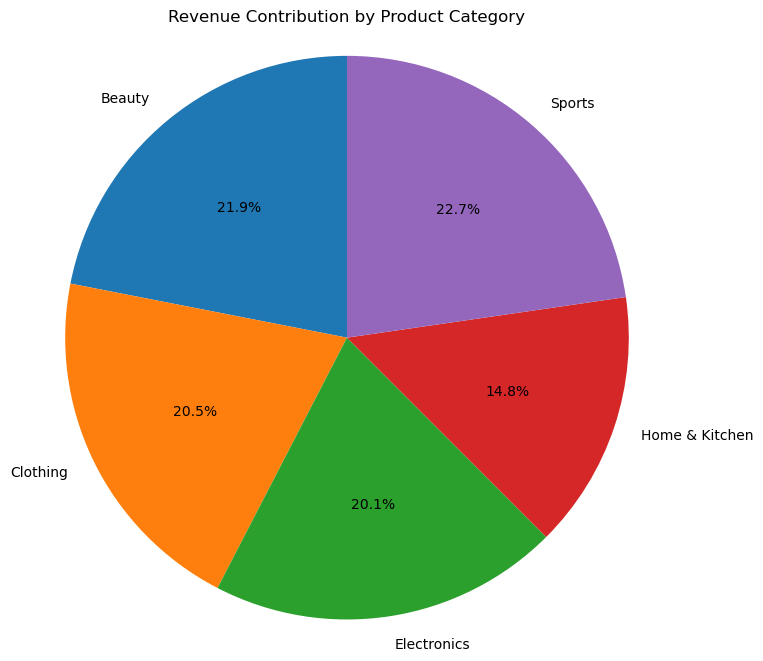

In [44]:
# 11. Create a pie chart of Revenue contribution by Product_Category. Display percentage values.
import matplotlib.pyplot as plt

# Revenue by Product Category
category_revenue = df.groupby('Product_Category')['Revenue'].sum()

plt.figure(figsize=(8, 8))
plt.pie(
    category_revenue,
    labels=category_revenue.index,
    autopct='%1.1f%%',   # Display percentage values
    startangle=90
)

plt.title('Revenue Contribution by Product Category')
plt.axis('equal')  # Makes the pie chart circular
plt.show()

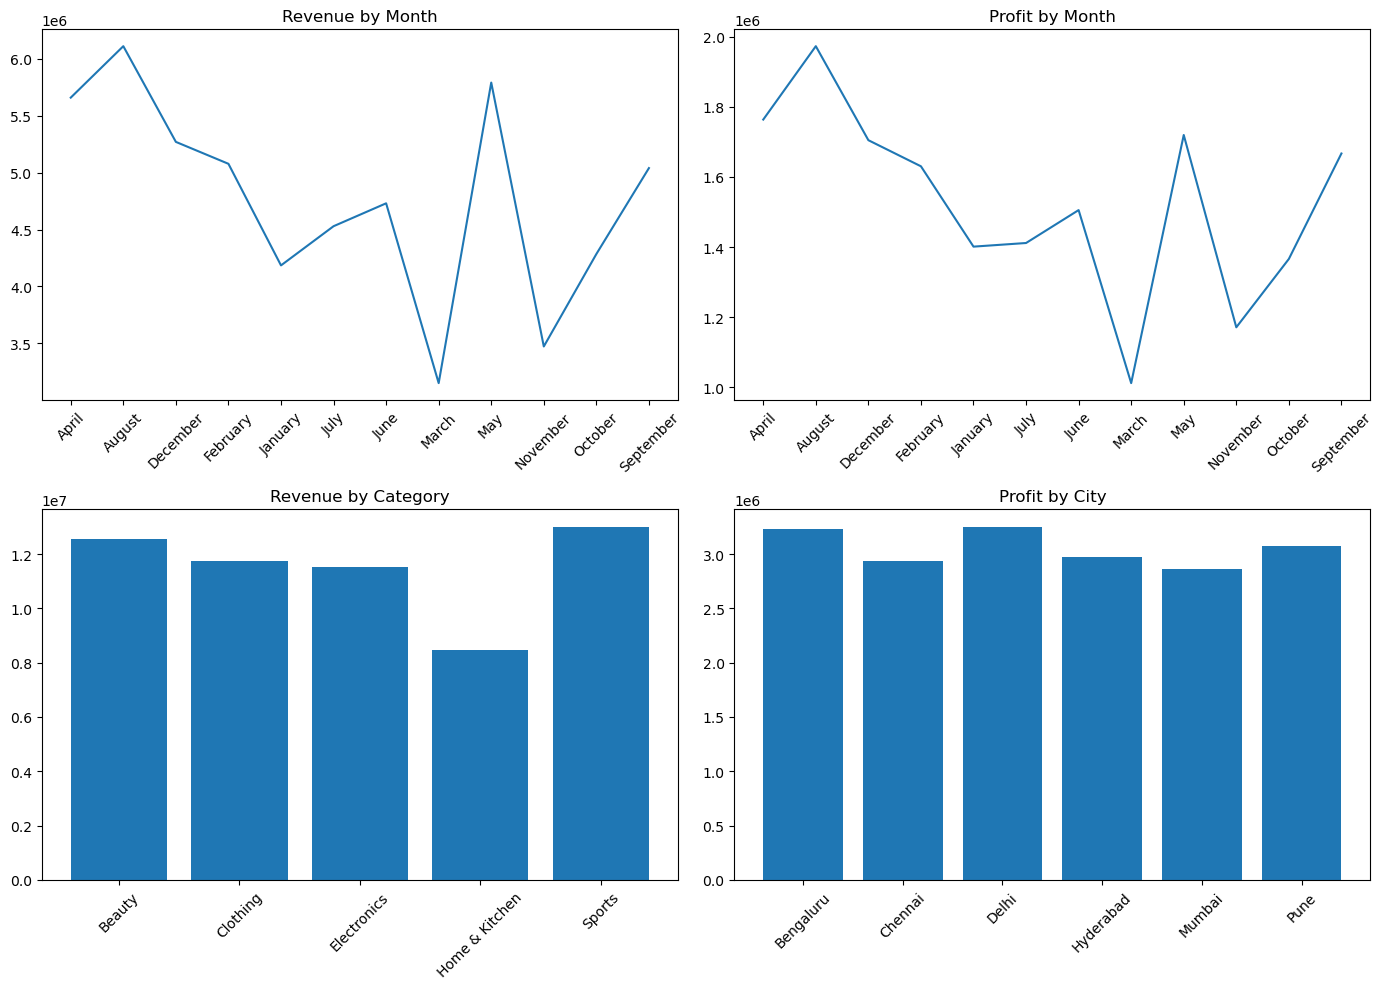

In [45]:
# 12. Create a 2×2 subplot containing:
# o Revenue by month
# o Profit by month
# o Revenue by category
# o Profit by city


monthly = df.groupby(df['Order_Date'].dt.month_name()).agg({
    'Revenue':'sum',
    'Profit':'sum'
})

category_rev = df.groupby('Product_Category')['Revenue'].sum()
city_profit = df.groupby('City')['Profit'].sum()

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Revenue by Month
ax[0,0].plot(monthly.index, monthly['Revenue'])
ax[0,0].set_title('Revenue by Month')
ax[0,0].tick_params(axis='x', rotation=45)

# Profit by Month
ax[0,1].plot(monthly.index, monthly['Profit'])
ax[0,1].set_title('Profit by Month')
ax[0,1].tick_params(axis='x', rotation=45)

# Revenue by Category
ax[1,0].bar(category_rev.index, category_rev.values)
ax[1,0].set_title('Revenue by Category')
ax[1,0].tick_params(axis='x', rotation=45)

# Profit by City
ax[1,1].bar(city_profit.index, city_profit.values)
ax[1,1].set_title('Profit by City')
ax[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

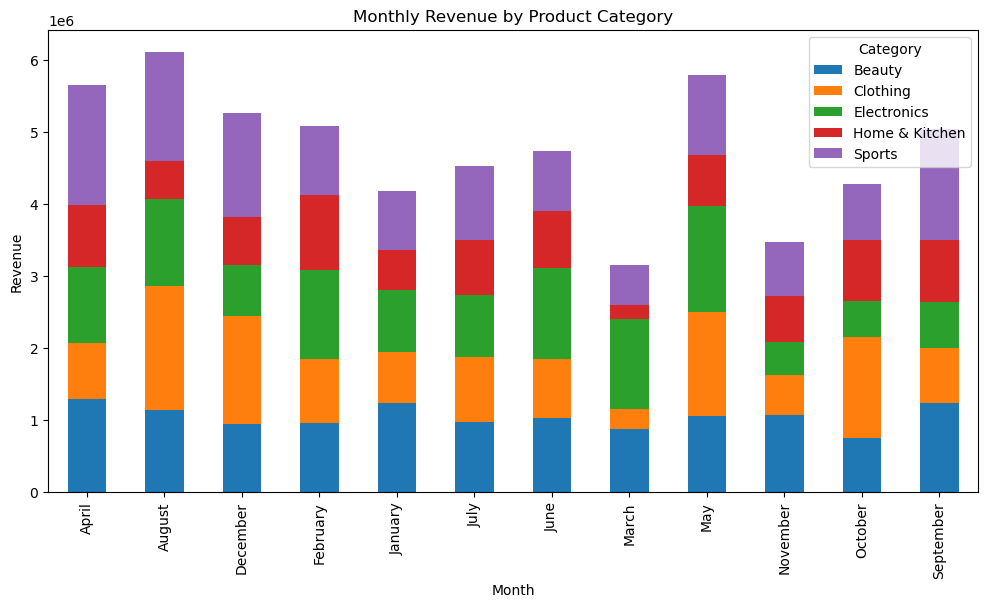

In [46]:
# 13. Create a stacked bar chart showing Revenue by month for each Product_Category.
monthly_category = pd.pivot_table(
    df,
    values='Revenue',
    index=df['Order_Date'].dt.month_name(),
    columns='Product_Category',
    aggfunc='sum'
)

monthly_category.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Monthly Revenue by Product Category')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.legend(title='Category')
plt.show()

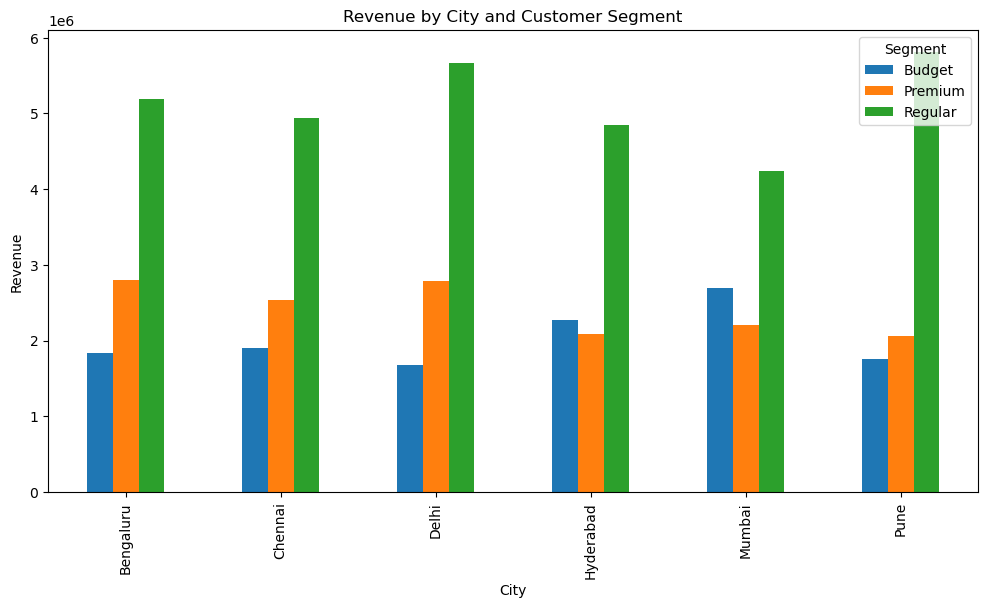

In [47]:
# 14. Create a grouped bar chart comparing Revenue across cities for different customer segments.


city_segment = pd.pivot_table(
    df,
    values='Revenue',
    index='City',
    columns='Customer_Segment',
    aggfunc='sum'
)

city_segment.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Revenue by City and Customer Segment')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.legend(title='Segment')
plt.show()

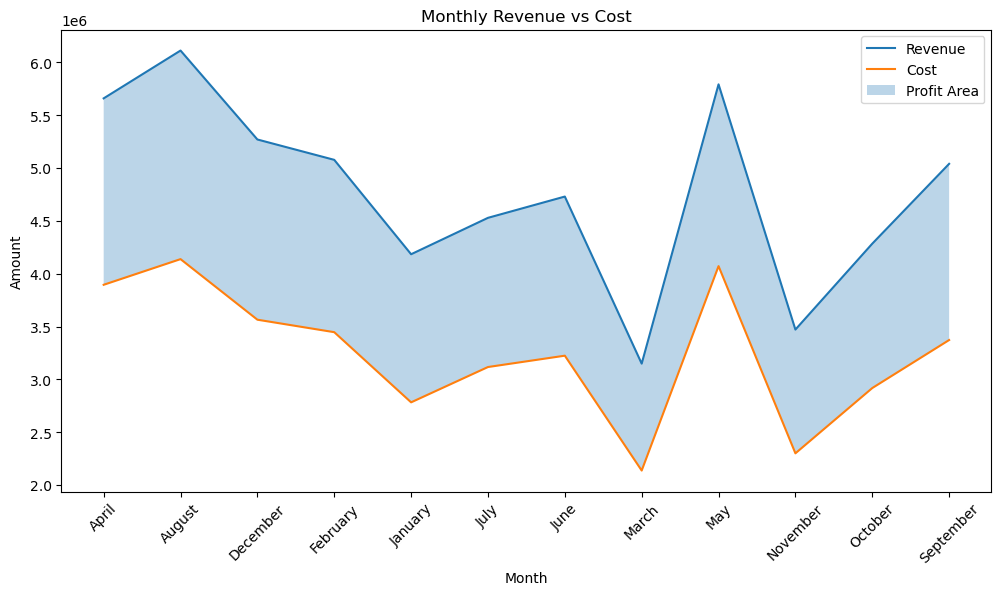

In [48]:
# 15. Plot monthly Revenue and Cost together and shade the area between the two lines to represent Profit.

monthly_data = df.groupby(df['Order_Date'].dt.month_name()).agg({
    'Revenue':'sum',
    'Cost':'sum'
})

plt.figure(figsize=(12,6))

plt.plot(monthly_data.index, monthly_data['Revenue'],
         label='Revenue')

plt.plot(monthly_data.index, monthly_data['Cost'],
         label='Cost')

plt.fill_between(
    monthly_data.index,
    monthly_data['Revenue'],
    monthly_data['Cost'],
    alpha=0.3,
    label='Profit Area'
)

plt.title('Monthly Revenue vs Cost')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)
plt.show()

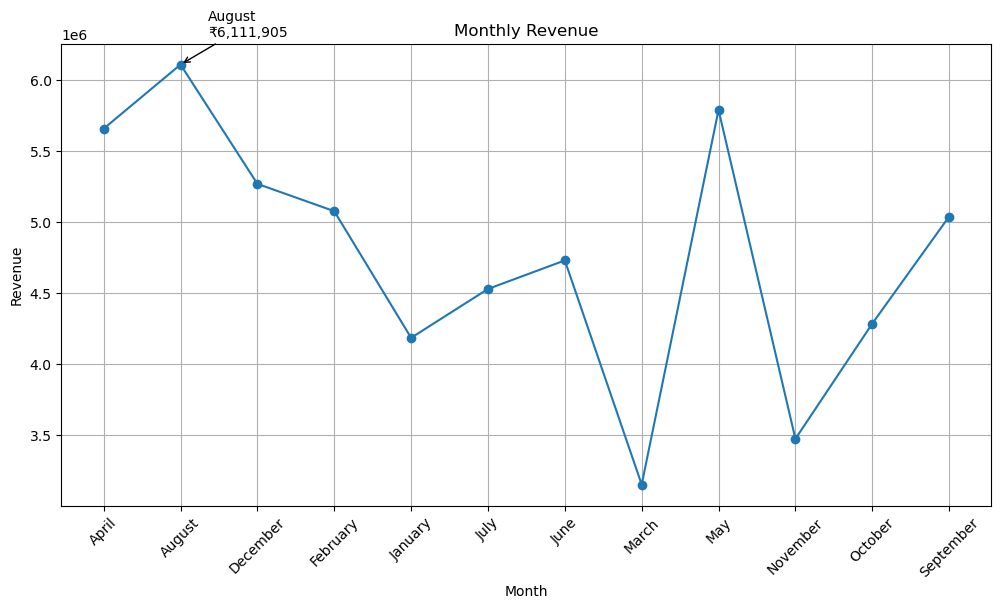

In [49]:
# 16. Find the month with the highest Revenue and annotate that point on the line chart.
monthly_revenue = df.groupby(
    df['Order_Date'].dt.month_name()
)['Revenue'].sum()

highest_month = monthly_revenue.idxmax()
highest_revenue = monthly_revenue.max()

plt.figure(figsize=(12,6))

plt.plot(monthly_revenue.index,
         monthly_revenue.values,
         marker='o')

plt.annotate(
    f'{highest_month}\n₹{highest_revenue:,.0f}',
    xy=(highest_month, highest_revenue),
    xytext=(20,20),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)

plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

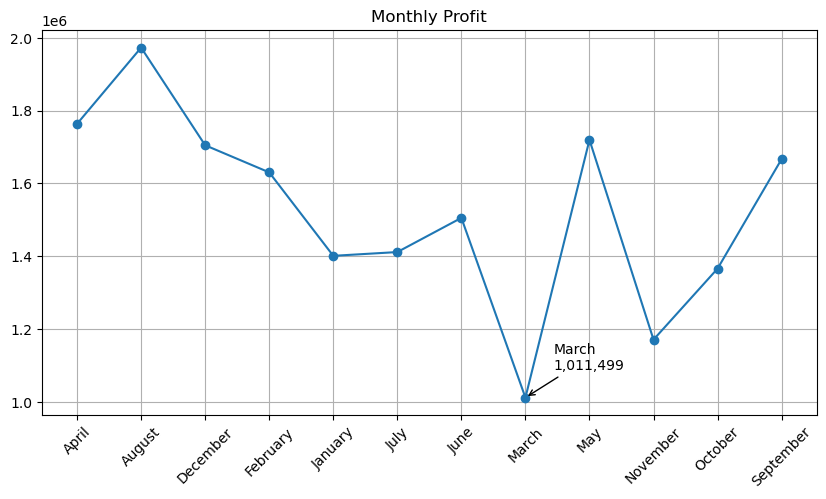

In [50]:
# 17. Find the month with the lowest Profit and annotate it on the visualization.
monthly_profit = df.groupby(df['Order_Date'].dt.month_name())['Profit'].sum()

lowest_month = monthly_profit.idxmin()
lowest_profit = monthly_profit.min()

plt.figure(figsize=(10,5))
plt.plot(monthly_profit.index, monthly_profit.values, marker='o')

plt.annotate(
    f'{lowest_month}\n{lowest_profit:,.0f}',
    xy=(lowest_month, lowest_profit),
    xytext=(20,20),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)

plt.title('Monthly Profit')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

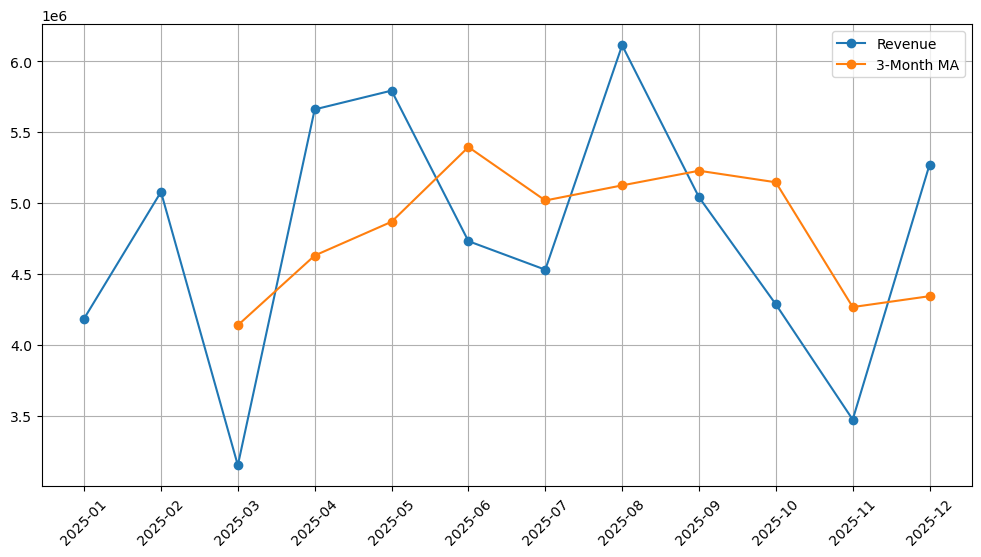

In [51]:
# 18. Create a line chart of monthly Revenue and calculate a 3-month moving average. Plot both lines together.
monthly_rev = df.groupby(df['Order_Date'].dt.to_period('M'))['Revenue'].sum()

ma3 = monthly_rev.rolling(3).mean()

plt.figure(figsize=(12,6))
plt.plot(monthly_rev.index.astype(str), monthly_rev.values,
         marker='o', label='Revenue')

plt.plot(monthly_rev.index.astype(str), ma3.values,
         marker='o', label='3-Month MA')

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

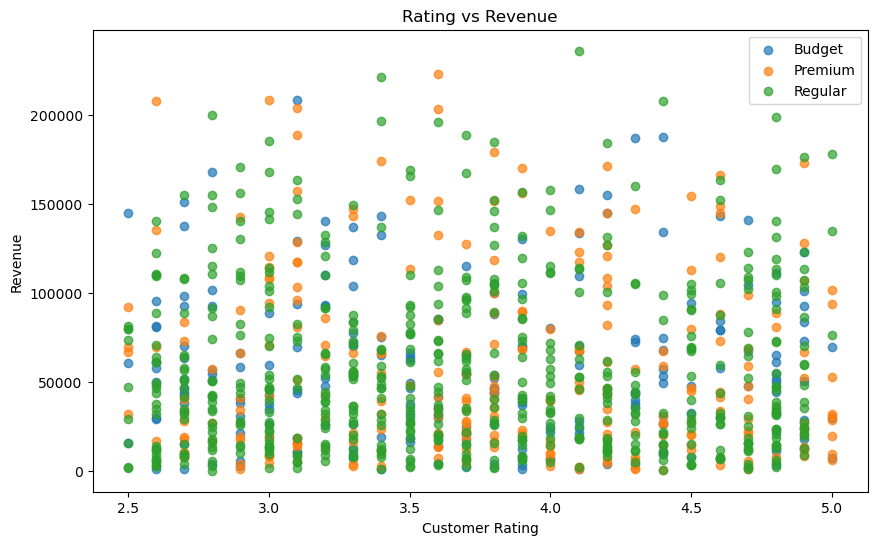

In [52]:
# 19. Create a scatter plot between Customer_Rating and Revenue. Use Customer_Segment to visually distinguish the points.
segments = df['Customer_Segment'].unique()

plt.figure(figsize=(10,6))

for seg in segments:
    temp = df[df['Customer_Segment']==seg]

    plt.scatter(
        temp['Customer_Rating'],
        temp['Revenue'],
        label=seg,
        alpha=0.7
    )

plt.xlabel("Customer Rating")
plt.ylabel("Revenue")
plt.title("Rating vs Revenue")
plt.legend()
plt.show()

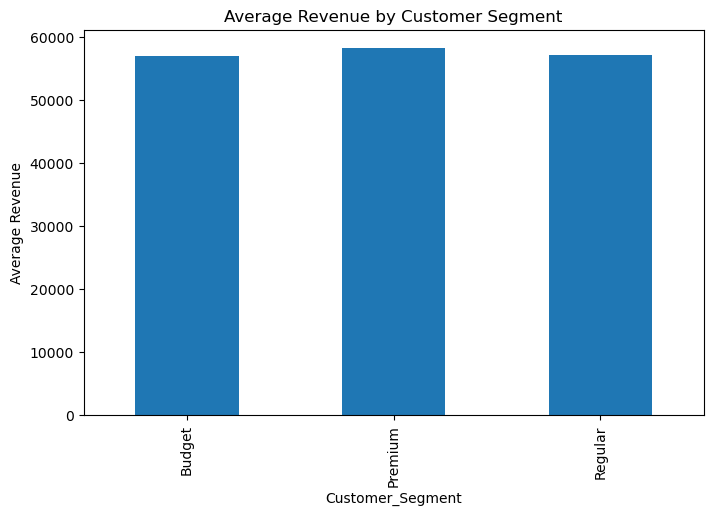

In [53]:
# 20. Create a visualization comparing the average Revenue of Premium, Regular, and Budget customers.
avg_rev = df.groupby('Customer_Segment')['Revenue'].mean()

avg_rev.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Revenue by Customer Segment")
plt.ylabel("Average Revenue")
plt.show()

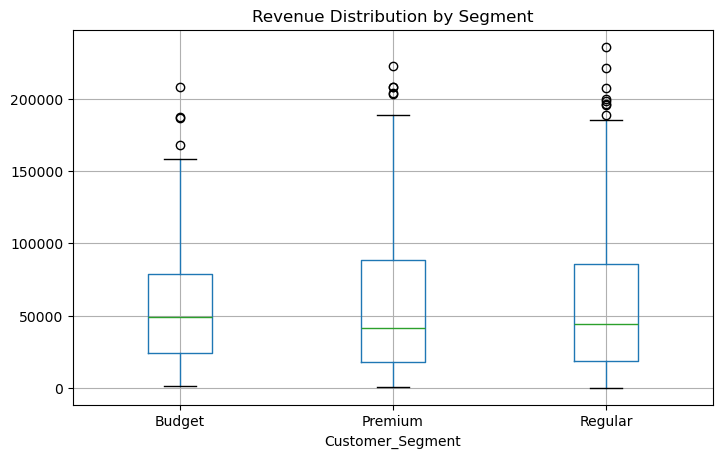

In [54]:
# 21. Create a boxplot of Revenue for each Customer_Segment. Compare the distributionsvisually.
df.boxplot(
    column='Revenue',
    by='Customer_Segment',
    figsize=(8,5)
)

plt.title("Revenue Distribution by Segment")
plt.suptitle("")
plt.show()

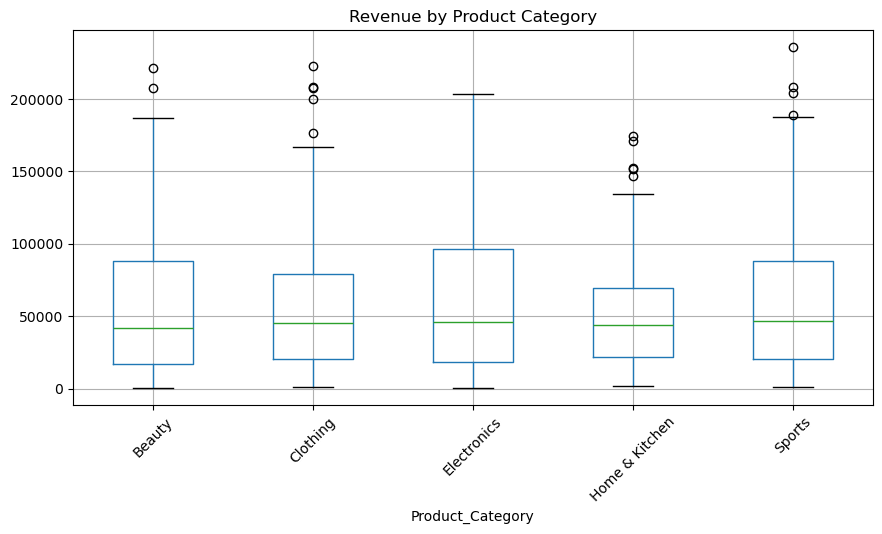

In [55]:
# 22. Create boxplots of Revenue for each Product_Category and identify which category has the largest spread.
df.boxplot(
    column='Revenue',
    by='Product_Category',
    figsize=(10,5)
)

plt.title("Revenue by Product Category")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

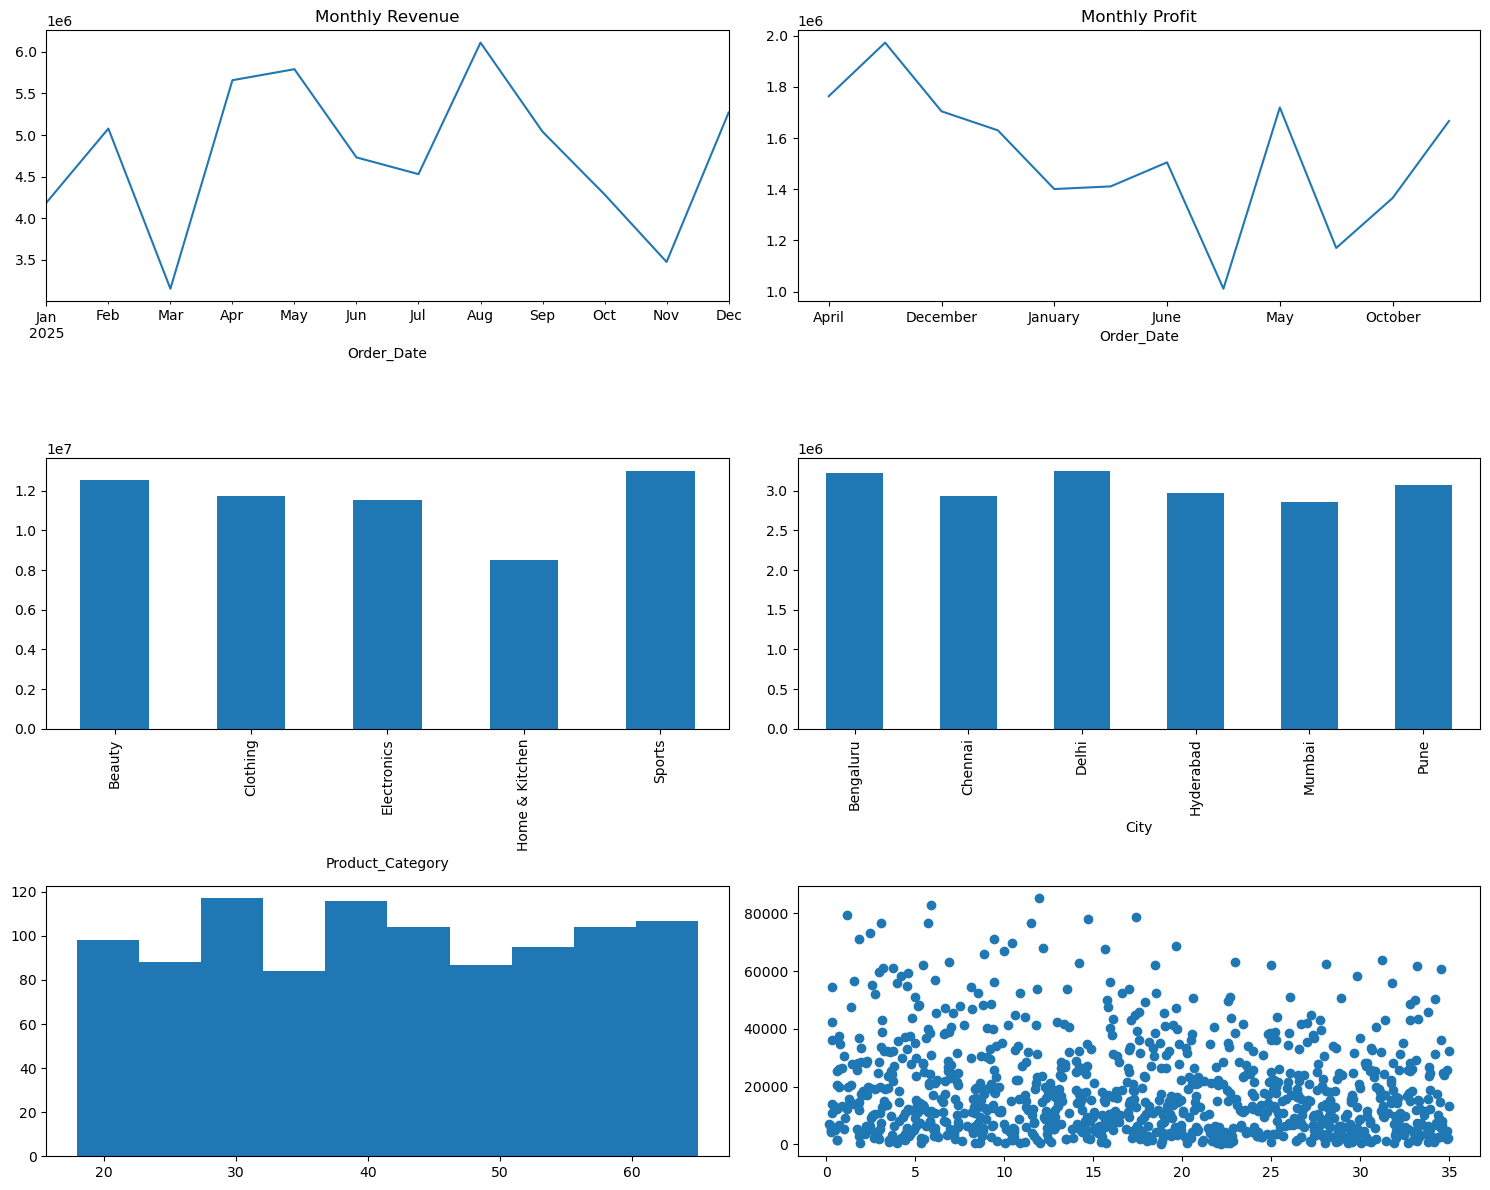

In [56]:
# 23. Create a 3×2 Matplotlib dashboard containing:
# o Monthly revenue
# o Monthly profit
# o Category revenue
# o City profit
# o Customer-age distribution
# o Discount vs profit
fig, ax = plt.subplots(3,2, figsize=(15,12))

# Monthly Revenue
monthly_rev.plot(ax=ax[0,0], title='Monthly Revenue')

# Monthly Profit
monthly_profit.plot(ax=ax[0,1], title='Monthly Profit')

# Category Revenue
df.groupby('Product_Category')['Revenue'].sum().plot(
    kind='bar', ax=ax[1,0]
)

# City Profit
df.groupby('City')['Profit'].sum().plot(
    kind='bar', ax=ax[1,1]
)

# Age Distribution
ax[2,0].hist(df['Customer_Age'], bins=10)

# Discount vs Profit
ax[2,1].scatter(df['Discount_Pct'], df['Profit'])

plt.tight_layout()
plt.show()

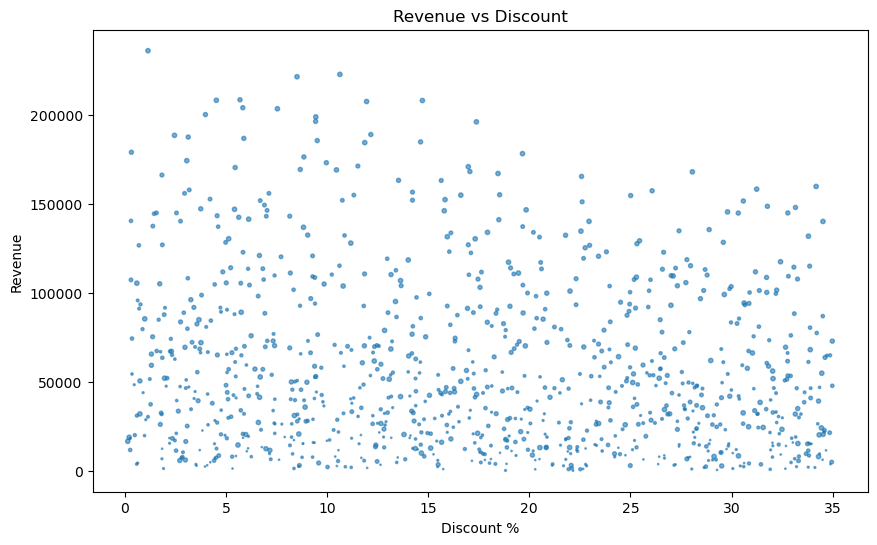

In [57]:
# 24. Create a chart showing Revenue vs Discount_Pct and use marker size to represent Units_Sold.
plt.figure(figsize=(10,6))

plt.scatter(
    df['Discount_Pct'],
    df['Revenue'],
    s=df['Units_Sold'],
    alpha=0.6
)

plt.xlabel("Discount %")
plt.ylabel("Revenue")
plt.title("Revenue vs Discount")
plt.show()

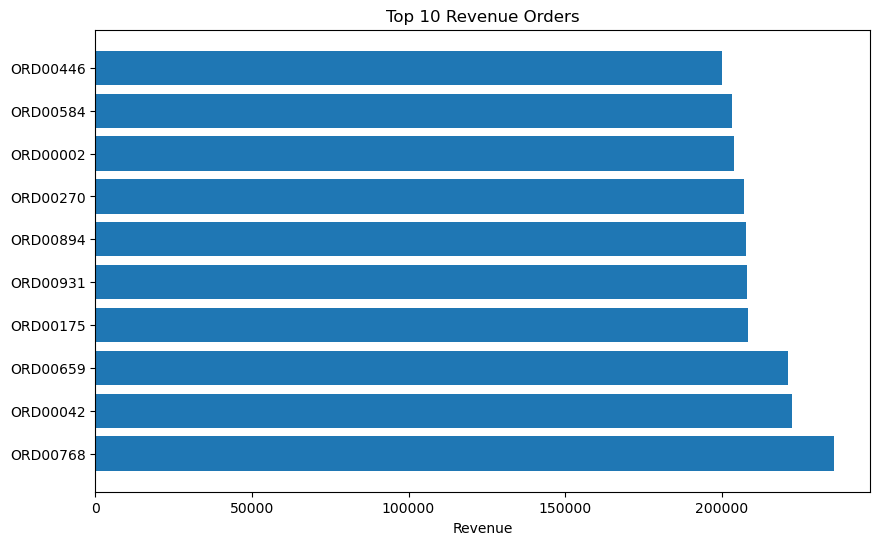

In [58]:
# 25. Identify the top 10 highest-revenue orders and visualize them using a horizontal bar chart. Display the Order_ID beside each bar.
top10 = df.nlargest(10,'Revenue')

plt.figure(figsize=(10,6))

plt.barh(
    top10['Order_ID'].astype(str),
    top10['Revenue']
)

plt.title("Top 10 Revenue Orders")
plt.xlabel("Revenue")
plt.show()

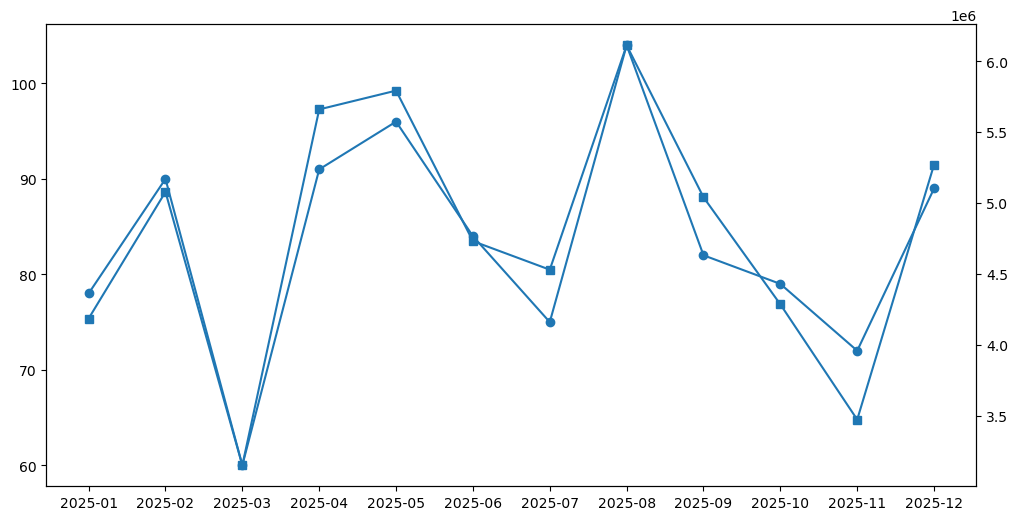

In [59]:
# 26. Create a visualization showing monthly Orders and Revenue using two Y-axes. Use the first Y-axis for order count and the second for revenue.
monthly_orders = df.groupby(
    df['Order_Date'].dt.to_period('M')
).size()

monthly_revenue = df.groupby(
    df['Order_Date'].dt.to_period('M')
)['Revenue'].sum()

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(
    monthly_orders.index.astype(str),
    monthly_orders.values,
    marker='o'
)

ax2 = ax1.twinx()

ax2.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker='s'
)

plt.xticks(rotation=45)
plt.show()

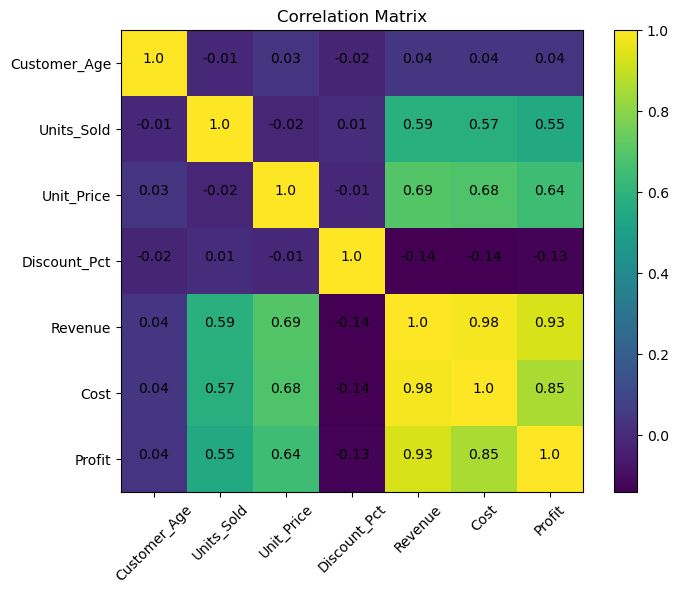

In [60]:
# 27. Create a heatmap-style visualization using Matplotlib only for the correlation matrix of:
# Customer_Age, Units_Sold, Unit_Price, Discount_Pct, Revenue, Cost, and Profit.
cols = [
    'Customer_Age',
    'Units_Sold',
    'Unit_Price',
    'Discount_Pct',
    'Revenue',
    'Cost',
    'Profit'
]

corr = df[cols].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(
            j, i,
            round(corr.iloc[i,j],2),
            ha='center'
        )

plt.title("Correlation Matrix")
plt.show()


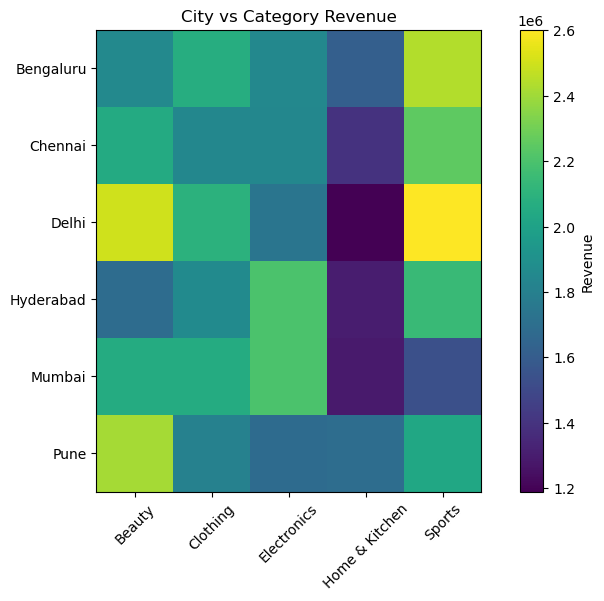

In [61]:
# 28. Create a dashboard comparing City × Product_Category Revenue. Use a suitable
# visualization to show which combinations generate the highest revenue.
pivot = pd.pivot_table(
    df,
    values='Revenue',
    index='City',
    columns='Product_Category',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))

plt.imshow(pivot)

plt.colorbar(label='Revenue')

plt.xticks(
    range(len(pivot.columns)),
    pivot.columns,
    rotation=45
)

plt.yticks(
    range(len(pivot.index)),
    pivot.index
)

plt.title("City vs Category Revenue")
plt.show()

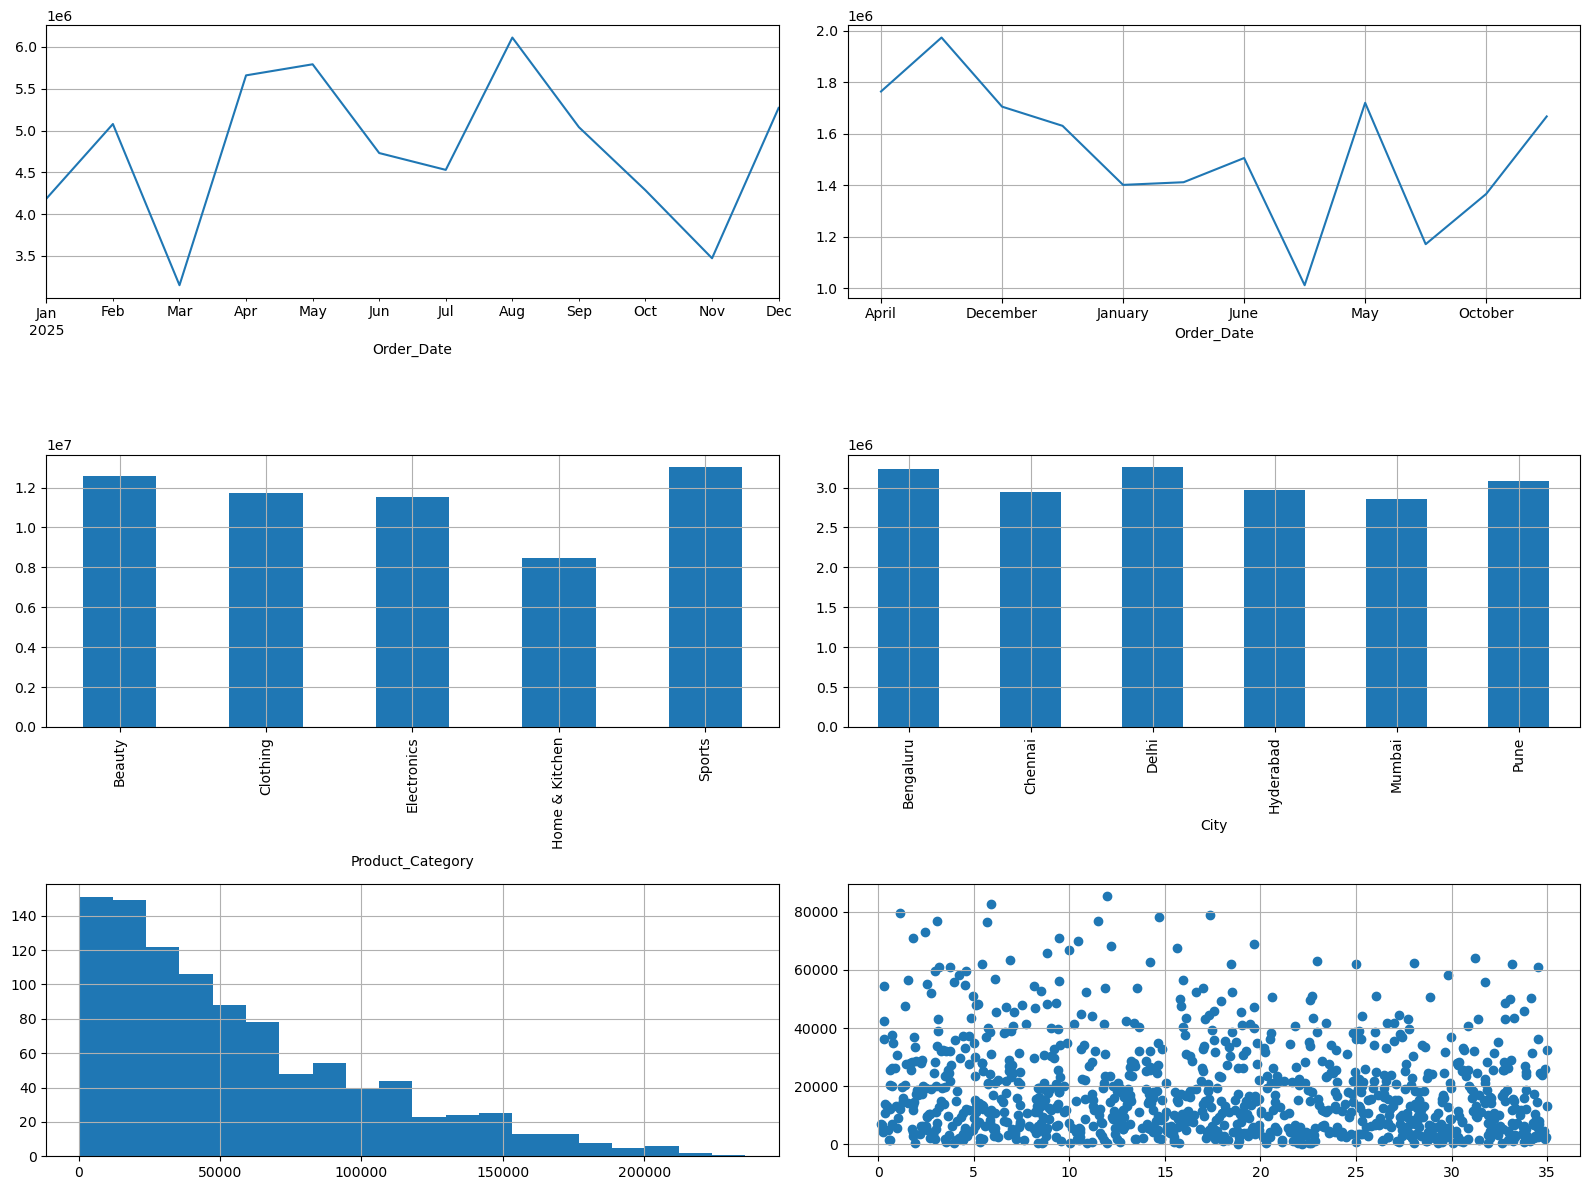

In [62]:
# 29. Create a complete sales performance dashboard with:
# o Monthly Revenue
# o Monthly Profit
# o Revenue by Category
# o Profit by City
# o Revenue distribution
# o Discount vs Profit
# Add titles, labels, legends, grids, annotations, and appropriate figure sizing.

fig, ax = plt.subplots(3,2, figsize=(16,12))

# Revenue
monthly_rev.plot(ax=ax[0,0])

# Profit
monthly_profit.plot(ax=ax[0,1])

# Category Revenue
df.groupby('Product_Category')['Revenue'].sum().plot(
    kind='bar', ax=ax[1,0]
)

# City Profit
df.groupby('City')['Profit'].sum().plot(
    kind='bar', ax=ax[1,1]
)

# Revenue Distribution
ax[2,0].hist(df['Revenue'], bins=20)

# Discount vs Profit
ax[2,1].scatter(
    df['Discount_Pct'],
    df['Profit']
)

for axes in ax.flat:
    axes.grid(True)

plt.tight_layout()
plt.show()

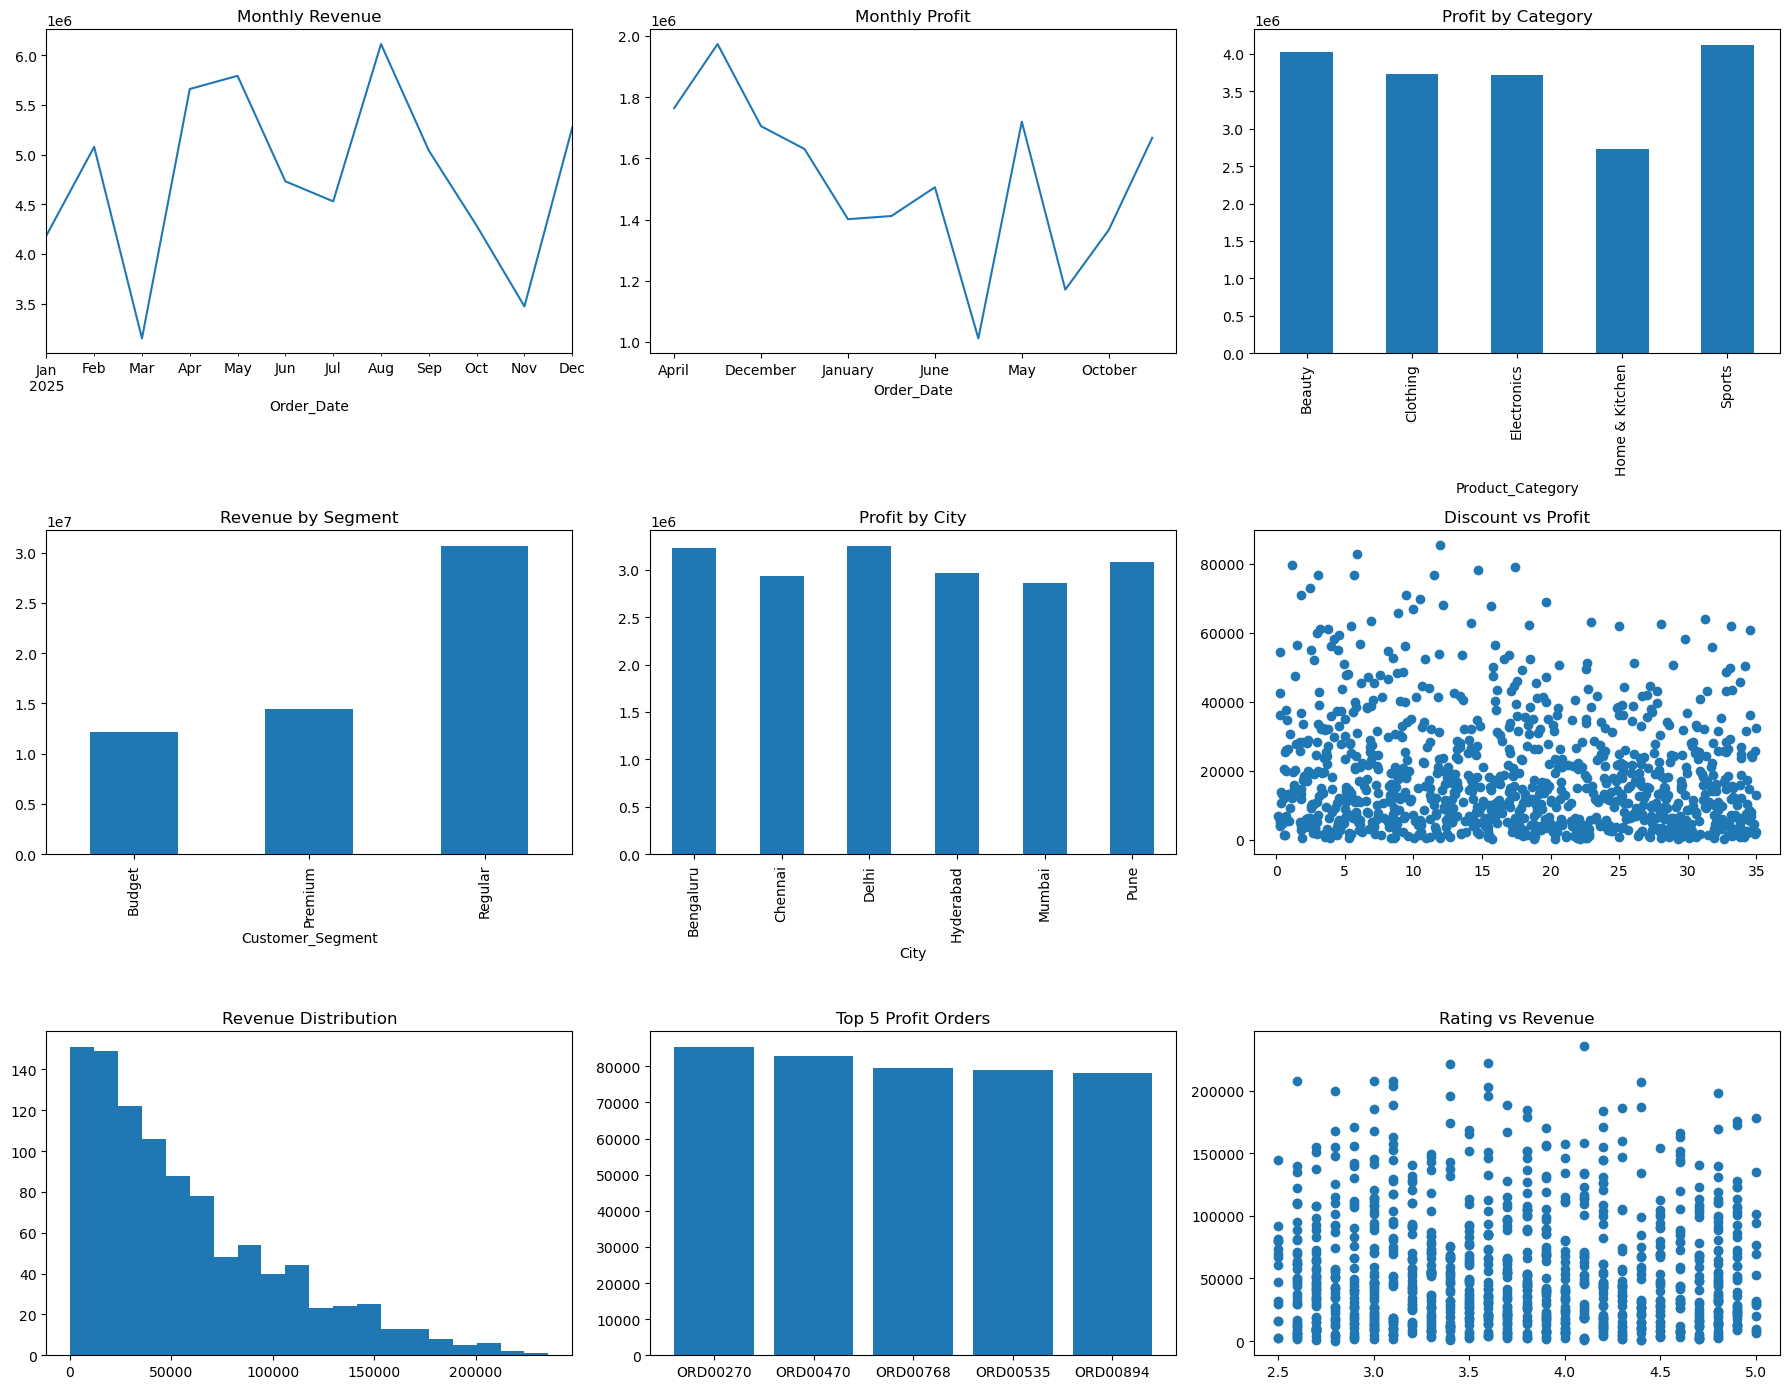

In [63]:
# 30. Final Challenge — Business Analytics Visualization
# Using the complete dataset, create a professional Matplotlib dashboard that answers:

# o Which month generated the highest revenue?
# o Which product category generated the highest profit?
# o Which city performed best?
# o Which customer segment generated the most revenue?
# o Does discount appear to affect profit?
# o What is the distribution of order revenue?
# o Which 5 orders generated the highest profit?

# Use at least 6 different visualizations, combine them into subplots, and add meaningful annotations to the important findings.
fig, ax = plt.subplots(3,3, figsize=(18,14))

# 1 Monthly Revenue
monthly_rev.plot(ax=ax[0,0], title='Monthly Revenue')

# 2 Monthly Profit
monthly_profit.plot(ax=ax[0,1], title='Monthly Profit')

# 3 Profit by Category
df.groupby('Product_Category')['Profit'].sum().plot(
    kind='bar',
    ax=ax[0,2],
    title='Profit by Category'
)

# 4 Revenue by Segment
df.groupby('Customer_Segment')['Revenue'].sum().plot(
    kind='bar',
    ax=ax[1,0],
    title='Revenue by Segment'
)

# 5 Profit by City
df.groupby('City')['Profit'].sum().plot(
    kind='bar',
    ax=ax[1,1],
    title='Profit by City'
)

# 6 Discount vs Profit
ax[1,2].scatter(
    df['Discount_Pct'],
    df['Profit']
)
ax[1,2].set_title("Discount vs Profit")

# 7 Revenue Distribution
ax[2,0].hist(df['Revenue'], bins=20)
ax[2,0].set_title("Revenue Distribution")

# 8 Top 5 Profit Orders
top5 = df.nlargest(5,'Profit')

ax[2,1].bar(
    top5['Order_ID'].astype(str),
    top5['Profit']
)
ax[2,1].set_title("Top 5 Profit Orders")

# 9 Rating vs Revenue
ax[2,2].scatter(
    df['Customer_Rating'],
    df['Revenue']
)
ax[2,2].set_title("Rating vs Revenue")

plt.tight_layout()
plt.show()